<table width="100%" style="border: none; border-collapse: collapse;">
  <tr>
    <td align="center" width="55%" style="border: none;">
      <h2>Centro de Investigación en Matemáticas, A.C.</h2>
    </td>
  </tr>
</table>


<h3 align="center">Evaluación del desempeño de K-Vecinos mas cercanos, utilizando las el conjunto test_set_rgb, exclueyndo la categoria sin etiqueta</h3>

<h4 align="center">Autor: Sarahi Ventura Angoa</h4>

<p align="center">Maestría en Cómputo Estadístico - CIMAT Mty</p>
<p align="center"> Septiembre 2025</p>


<div class="alert alert-block alert-info" role="alert" style="margin-top:8px">
  <h4 style="margin-top:0">Evaluación del desempeño por imagen</h4>
  <p style="margin:0 0 10px 0;">
    Este <code>notebook</code> realiza una comparacion del desempeño de los modelos entrenados con los mejores hiperparametros encontrados sobre el conjunto de 23 imágenes completamente etiquetadas de forma manual <i>test_set_rgb</i>. 
    Para cada imagen se calculan las siguientes salidas:
  </p>
  <ul style="margin-top:0;">
    <li>Matriz de confusión por imagen (10 clases)</li>
    <li>Precisión por clase (solo clases presentes en ambas fuentes)</li>
    <li>Conteo total de errores de predicción</li>
    <li>Reporte detallado de confusiones (Caso 3)</li>
  </ul>
</div>



#
<div class="alert alert-block alert-success">
<b>Importacion de las librerias</b></div>

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from pathlib import Path

#
<div class="alert alert-block alert-success">
<b>Diccionario de las categorías </b></div>

In [2]:
# Diccionario de las categorías 
categorias = {
    0: "Árbol",
    1: "Suelo desnudo",
    2: "Pavimento",
    3: "Cuerpo de agua",
    4: "Techo de lámina",
    5: "Techo de losa",
    6: "Arbusto",
    7: "Hierba y pasto seco",
    8: "Hierba y pasto verde",
    9: "Sombra",
    10: "Sin etiqueta"
}

Ruta donde estan los archivos *.csv*
* Caract_paralelo_ 
* Etiquetado_ 

In [3]:
# =========================================================
# RUTAS
# =========================================================
ruta_etiquetas_manuales = Path("/home/victor/Documents/prueba_modelos/etiquetadas_prueba")
ruta_predicciones_modelo = Path("/home/victor/Documents/prediccion_img_prueba_knn")  


# =========================================================
# LISTA DE ARCHIVOS
# =========================================================

archivos_etiquetados = [
    f for f in os.listdir(ruta_etiquetas_manuales)
    if f.startswith("Etiquetado_") and f.endswith(".csv")
]

archivos_caract = [
    f for f in os.listdir(ruta_predicciones_modelo)
    if f.startswith("Caract_paralelo_") and f.endswith(".csv")
]


<div class="alert alert-block alert-info" role="alert" style="margin-top:8px">
  <p style="margin:0 0 10px 0;">
    Se consideran únicamente los <strong>Casos 1, 2 y 3</strong> y se <strong>ignoran</strong> las categorías ausentes en ambas fuentes (Caso 4).
  </p>

  <ul style="margin-top:0;">
    <li><strong>Caso 1 (Coincidencias, TP):</strong> la clase aparece tanto en las etiquetas reales como en las predicciones (verdaderos positivos a nivel de superpíxel).</li>
    <li><strong>Caso 2 (Clases omitidas, FN):</strong> la clase está presente en las etiquetas reales pero el modelo no logra predecir bien esa clase.</li>
    <li><strong>Caso 3 (Clases inventadas, FP):</strong> la clase aparece en las predicciones pero no está en las etiquetas reales.</li>
    <li><strong>Caso 4 (Ausentes en ambas):</strong> la clase no aparece en ninguna de las dos fuentes; se <em>omite</em> del análisis.</li>
  </ul>

  <h4 style="margin:10px 0 6px 0;">Métricas</h4>
  <p style="margin:0 0 8px 0;">
    <ul>
      <li>precision</li>
      <li>Recall</li>
      <li>F1-score</li>
    </ul>
    y weighted
  </p>
</div>

<div class="alert alert-block alert-info" role="alert" style="margin-top:8px">
  <h4 style="margin:10px 0 6px 0;">Reporte de errores (Caso 3)</h4>
  <p style="margin:0;">
    Se genera un informe detallado por imagen con las <strong>clases predichas erróneamente</strong> (no presentes en las etiquetas reales), indicando para cada una de ellas las <em>clases verdaderas</em> con las que se confundieron y el <em>número de ocurrencias</em>. Las <strong>clases ausentes en ambas fuentes</strong> (Caso 4) no se incluyen por carecer de valor informativo en la evaluación del desempeño.
  </p>
</div>



* Reporte de clases predichas erróneamente en 'image_x5_176':
--------------------------------------------------------
'Cuerpo de agua' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Sombra: 2 veces
   Total de errores para esta clase: 2

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Pavimento: 10 veces
   - Techo de losa: 3 veces
   Total de errores para esta clase: 13



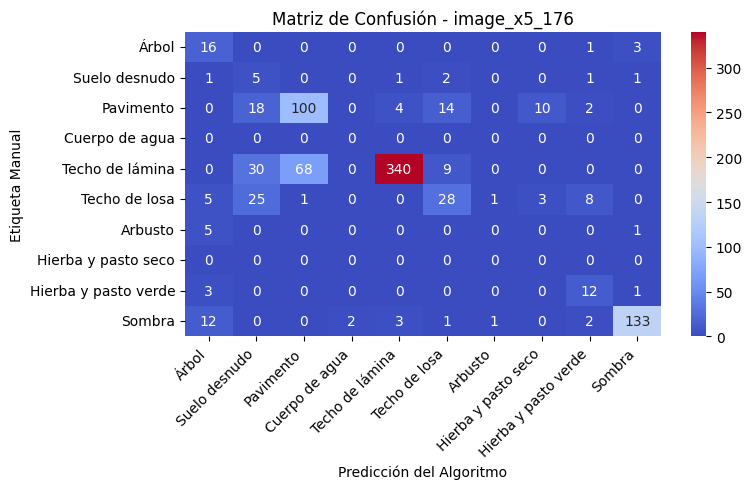


* Reporte de clases predichas erróneamente en 'image_x5_1730':
--------------------------------------------------------
'Pavimento' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 1 veces
   - Cuerpo de agua: 38 veces
   Total de errores para esta clase: 39

'Techo de lámina' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Cuerpo de agua: 7 veces
   Total de errores para esta clase: 7

'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Cuerpo de agua: 11 veces
   - Sombra: 2 veces
   Total de errores para esta clase: 13

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 3 veces
   - Cuerpo de agua: 1 veces
   - Hierba y pasto verde: 2 veces
   Total de errores para esta clase: 6



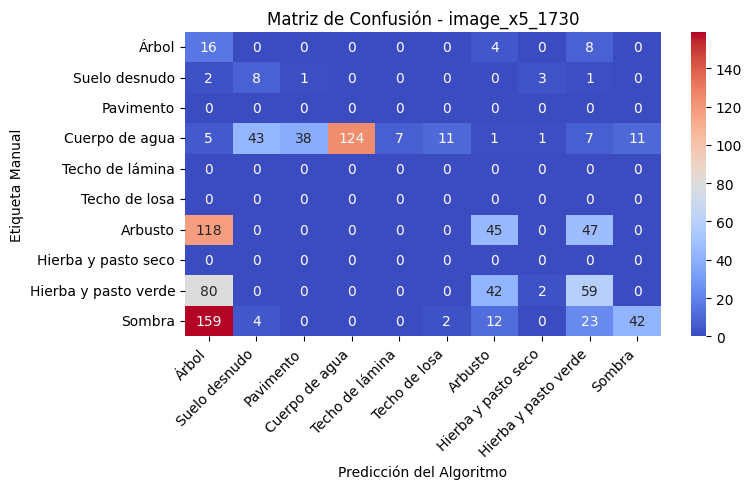


* Reporte de clases predichas erróneamente en 'image_x5_3628':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 6 veces
   - Pavimento: 34 veces
   - Techo de losa: 5 veces
   - Hierba y pasto verde: 2 veces
   Total de errores para esta clase: 47

Clases ausentes en ambos archivos:
 - Cuerpo de agua


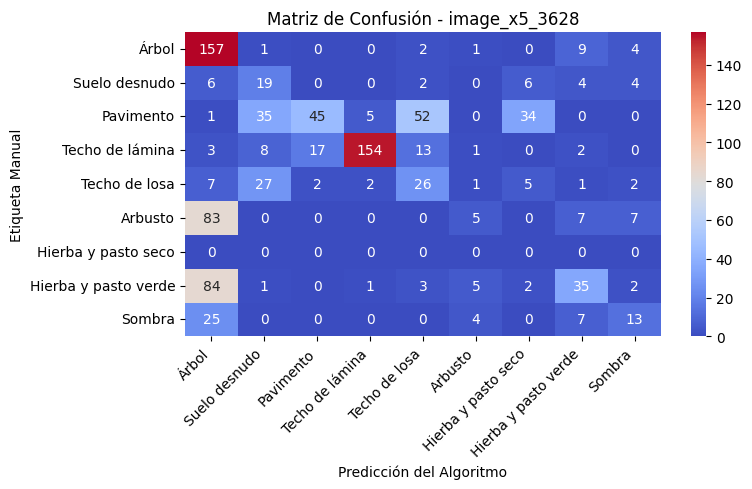


* Reporte de clases predichas erróneamente en 'image_x5_1797':
--------------------------------------------------------
'Cuerpo de agua' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Sombra: 2 veces
   Total de errores para esta clase: 2

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 2 veces
   - Pavimento: 3 veces
   - Techo de lámina: 3 veces
   - Techo de losa: 5 veces
   Total de errores para esta clase: 13



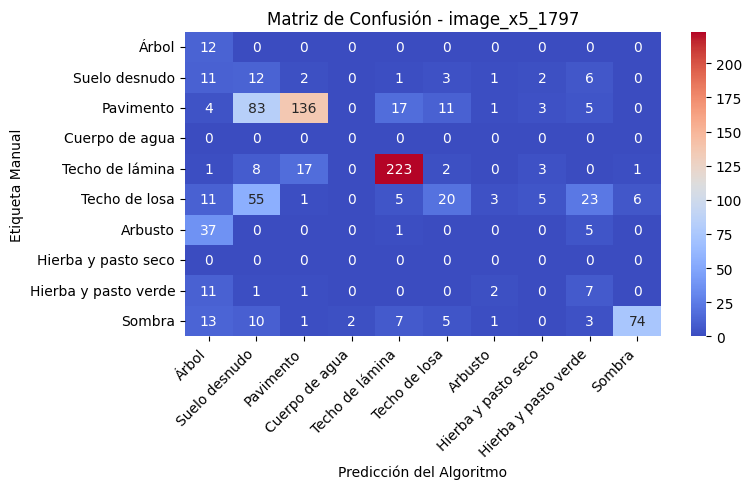


* Reporte de clases predichas erróneamente en 'image_x5_172':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 2 veces
   - Pavimento: 5 veces
   - Techo de lámina: 5 veces
   - Techo de losa: 2 veces
   Total de errores para esta clase: 14

'Sombra' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Árbol: 1 veces
   - Suelo desnudo: 5 veces
   - Pavimento: 1 veces
   - Techo de lámina: 5 veces
   - Techo de losa: 1 veces
   Total de errores para esta clase: 13

Clases ausentes en ambos archivos:
 - Cuerpo de agua


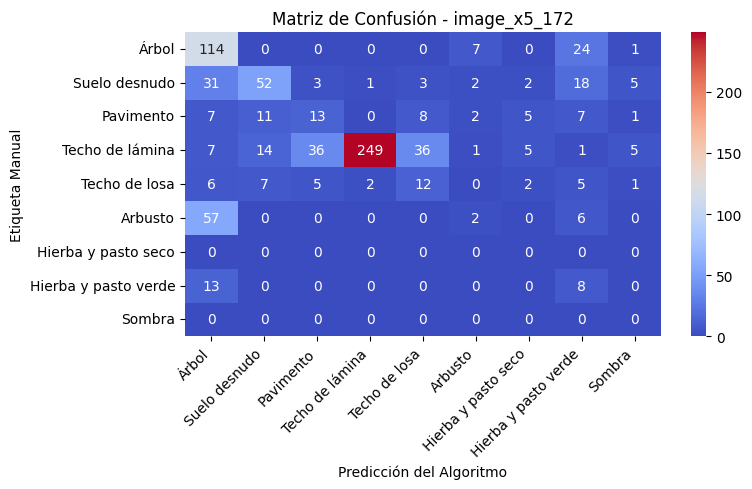


* Reporte de clases predichas erróneamente en 'image_x5_221':
--------------------------------------------------------
'Cuerpo de agua' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 1 veces
   Total de errores para esta clase: 1

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 14 veces
   - Pavimento: 6 veces
   - Techo de lámina: 1 veces
   - Techo de losa: 2 veces
   Total de errores para esta clase: 23



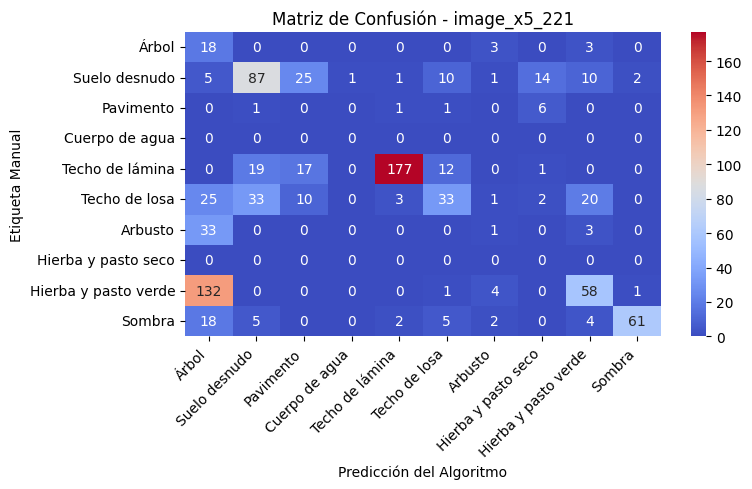


* Reporte de clases predichas erróneamente en 'image_x5_3913':
--------------------------------------------------------
'Pavimento' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Cuerpo de agua: 18 veces
   Total de errores para esta clase: 18

'Techo de lámina' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 1 veces
   - Cuerpo de agua: 2 veces
   Total de errores para esta clase: 3

'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Cuerpo de agua: 6 veces
   - Sombra: 2 veces
   Total de errores para esta clase: 8



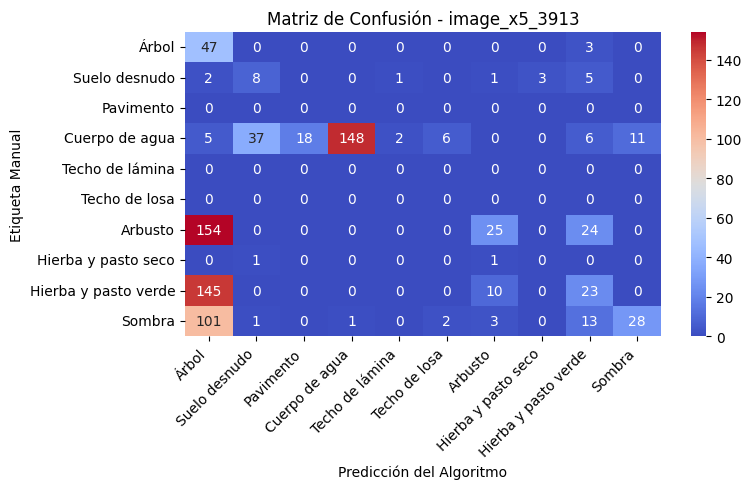


* Reporte de clases predichas erróneamente en 'image_x5_174':
--------------------------------------------------------
'Pavimento' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Techo de lámina: 28 veces
   Total de errores para esta clase: 28

'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Árbol: 1 veces
   - Suelo desnudo: 2 veces
   - Techo de lámina: 13 veces
   Total de errores para esta clase: 16

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 2 veces
   Total de errores para esta clase: 2

'Sombra' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Árbol: 1 veces
   - Suelo desnudo: 8 veces
   - Techo de lámina: 4 veces
   - Hierba y pasto verde: 13 veces
   Total de errores para esta clase: 26

Clases ausentes en ambos archivos:
 - Cuerpo de agua


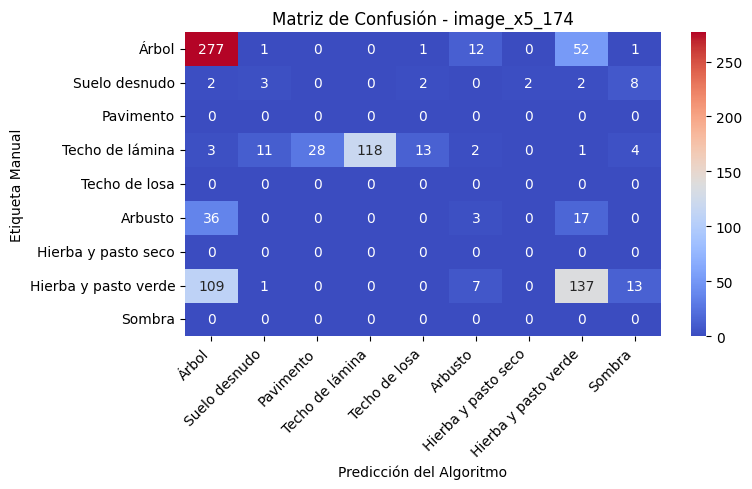


* Reporte de clases predichas erróneamente en 'image_x5_164':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 9 veces
   - Pavimento: 1 veces
   - Techo de lámina: 4 veces
   - Techo de losa: 1 veces
   Total de errores para esta clase: 15

Clases ausentes en ambos archivos:
 - Cuerpo de agua


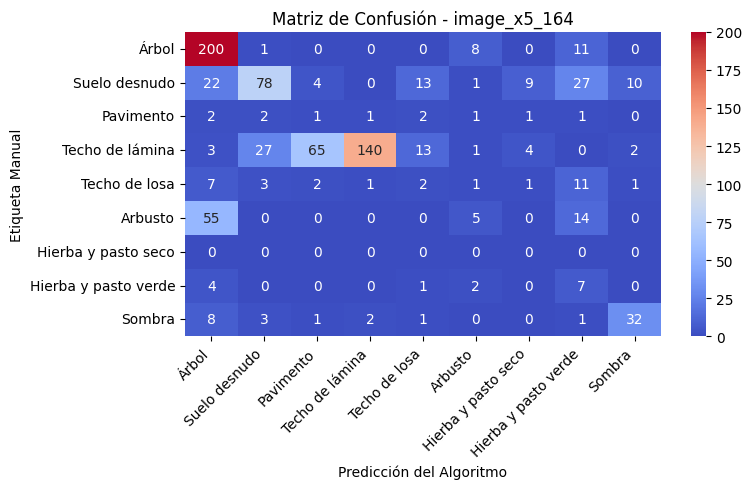


* Reporte de clases predichas erróneamente en 'image_x5_201':
--------------------------------------------------------
'Árbol' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 12 veces
   - Arbusto: 30 veces
   - Hierba y pasto verde: 8 veces
   - Sombra: 1 veces
   Total de errores para esta clase: 51

'Pavimento' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 51 veces
   - Techo de losa: 1 veces
   - Hierba y pasto verde: 1 veces
   - Sombra: 3 veces
   Total de errores para esta clase: 56

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 37 veces
   - Techo de lámina: 3 veces
   - Hierba y pasto verde: 3 veces
   Total de errores para esta clase: 43

Clases ausentes en ambos archivos:
 - Cuerpo de agua


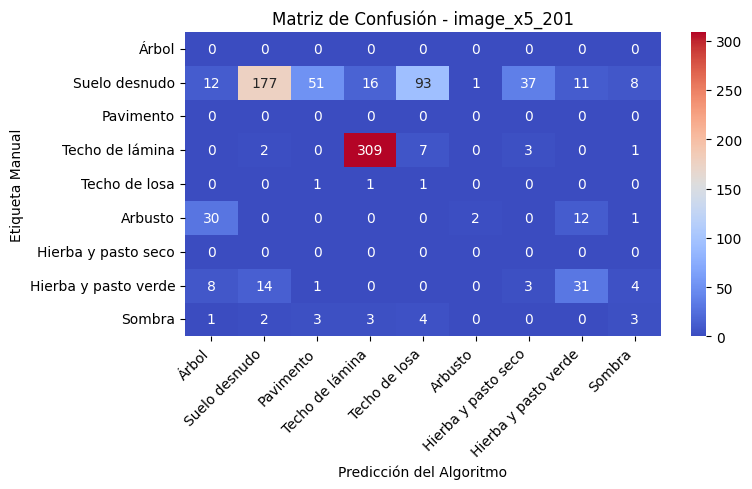


* Reporte de clases predichas erróneamente en 'image_x5_2471':
--------------------------------------------------------
'Cuerpo de agua' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Techo de lámina: 10 veces
   Total de errores para esta clase: 10

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Árbol: 4 veces
   - Suelo desnudo: 4 veces
   - Techo de lámina: 2 veces
   - Techo de losa: 3 veces
   Total de errores para esta clase: 13

'Sombra' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Árbol: 1 veces
   - Suelo desnudo: 6 veces
   - Pavimento: 1 veces
   - Techo de lámina: 11 veces
   - Arbusto: 2 veces
   - Hierba y pasto verde: 15 veces
   Total de errores para esta clase: 36



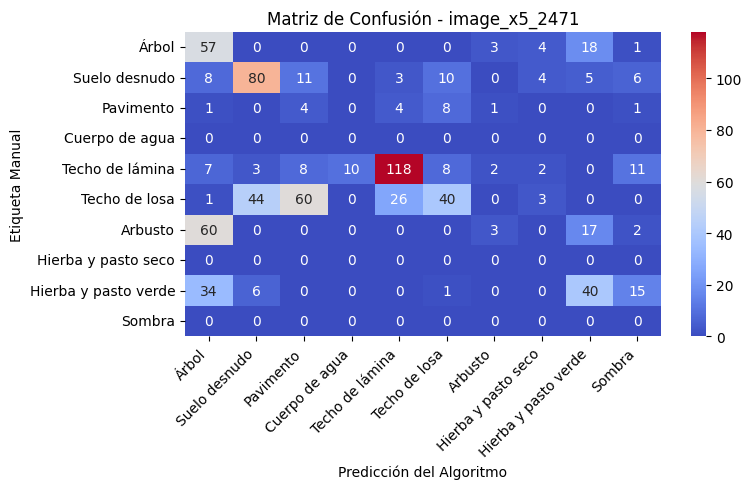


* Reporte de clases predichas erróneamente en 'image_x5_2486':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 3 veces
   - Pavimento: 1 veces
   - Techo de lámina: 5 veces
   - Techo de losa: 13 veces
   Total de errores para esta clase: 22

Clases ausentes en ambos archivos:
 - Cuerpo de agua


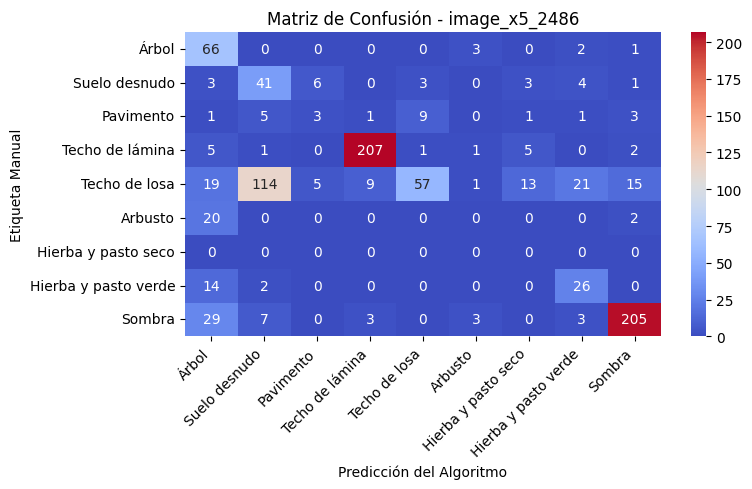


* Reporte de clases predichas erróneamente en 'image_x5_3378':
--------------------------------------------------------
'Cuerpo de agua' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Sombra: 1 veces
   Total de errores para esta clase: 1



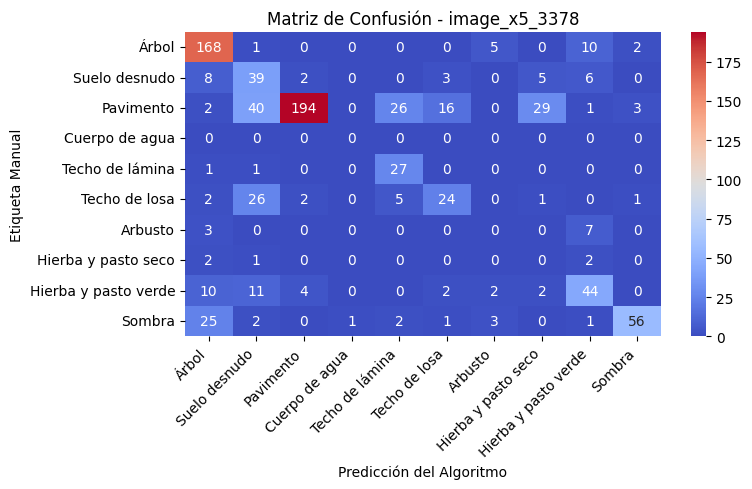


* Reporte de clases predichas erróneamente en 'image_x5_2983':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 10 veces
   - Pavimento: 4 veces
   - Techo de losa: 9 veces
   - Hierba y pasto verde: 1 veces
   Total de errores para esta clase: 24

Clases ausentes en ambos archivos:
 - Cuerpo de agua


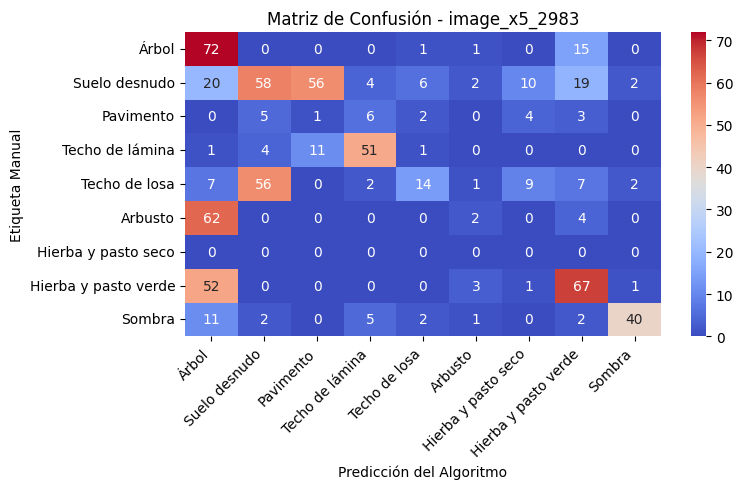


* Reporte de clases predichas erróneamente en 'image_x5_2868':
--------------------------------------------------------
'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 1 veces
   - Pavimento: 17 veces
   - Techo de lámina: 3 veces
   - Sombra: 1 veces
   Total de errores para esta clase: 22

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 3 veces
   - Pavimento: 21 veces
   - Techo de lámina: 4 veces
   Total de errores para esta clase: 28

Clases ausentes en ambos archivos:
 - Cuerpo de agua


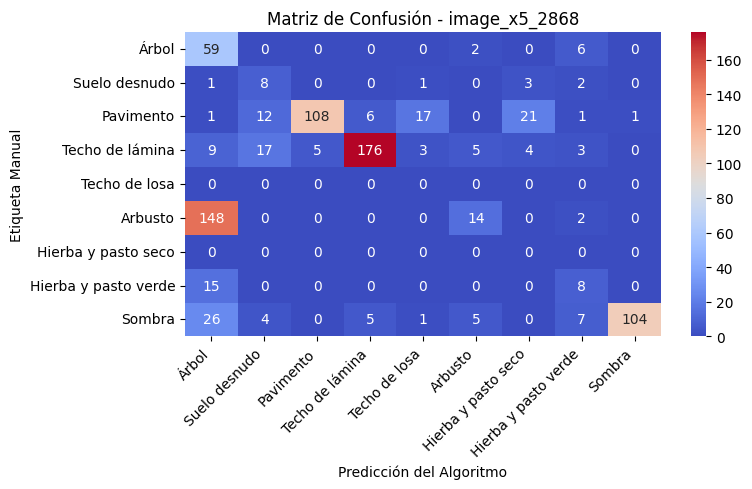


* Reporte de clases predichas erróneamente en 'image_x5_163':
--------------------------------------------------------
'Pavimento' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 7 veces
   - Techo de lámina: 14 veces
   - Techo de losa: 11 veces
   Total de errores para esta clase: 32

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 2 veces
   - Techo de losa: 3 veces
   - Hierba y pasto verde: 1 veces
   Total de errores para esta clase: 6

'Sombra' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Árbol: 9 veces
   - Suelo desnudo: 4 veces
   - Techo de lámina: 1 veces
   - Techo de losa: 26 veces
   - Hierba y pasto verde: 30 veces
   Total de errores para esta clase: 70

Clases ausentes en ambos archivos:
 - Cuerpo de agua


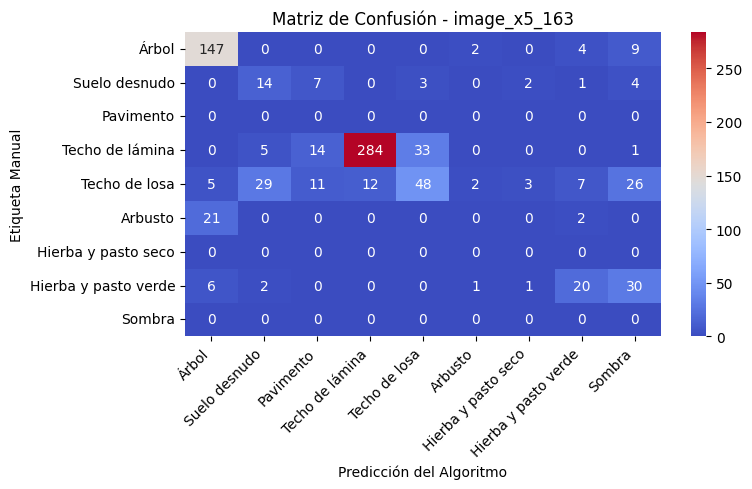


* Reporte de clases predichas erróneamente en 'image_x5_3425':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 23 veces
   - Techo de losa: 8 veces
   - Hierba y pasto verde: 8 veces
   Total de errores para esta clase: 39

Clases ausentes en ambos archivos:
 - Cuerpo de agua


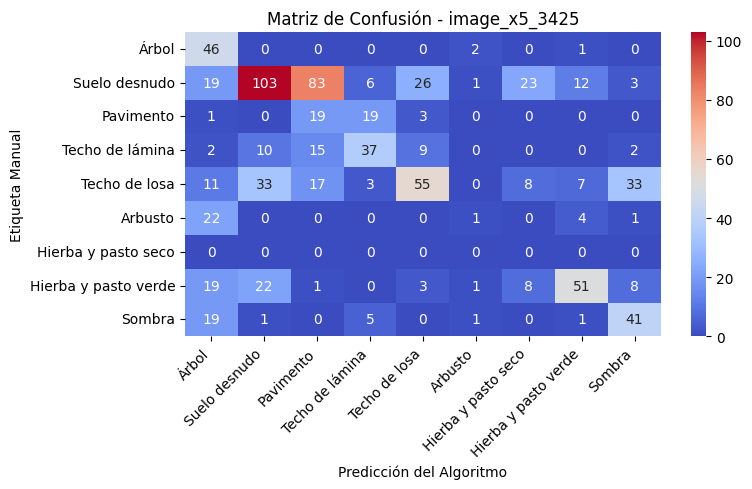


* Reporte de clases predichas erróneamente en 'image_x5_2502':
--------------------------------------------------------
'Pavimento' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 42 veces
   - Cuerpo de agua: 10 veces
   Total de errores para esta clase: 52

'Techo de lámina' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 1 veces
   Total de errores para esta clase: 1

'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 6 veces
   - Cuerpo de agua: 19 veces
   Total de errores para esta clase: 25

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 26 veces
   - Hierba y pasto verde: 1 veces
   Total de errores para esta clase: 27



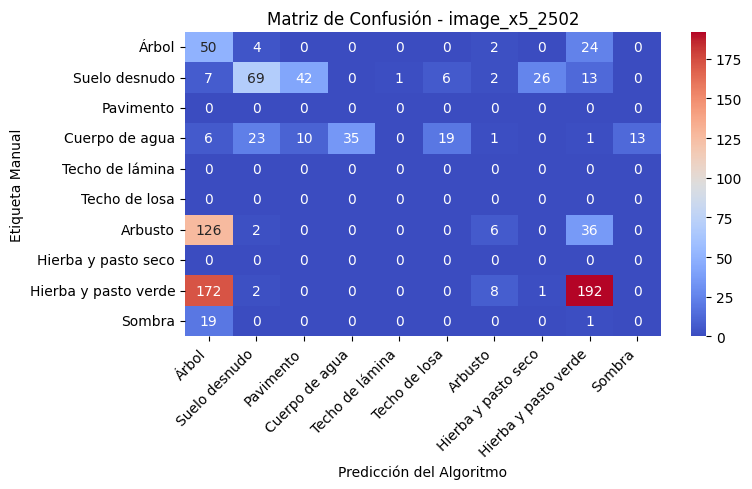


* Reporte de clases predichas erróneamente en 'image_x5_1272':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 2 veces
   - Pavimento: 12 veces
   - Techo de losa: 16 veces
   Total de errores para esta clase: 30

'Sombra' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Árbol: 2 veces
   - Suelo desnudo: 8 veces
   - Pavimento: 9 veces
   - Techo de losa: 6 veces
   - Arbusto: 3 veces
   - Hierba y pasto verde: 10 veces
   Total de errores para esta clase: 38

Clases ausentes en ambos archivos:
 - Cuerpo de agua


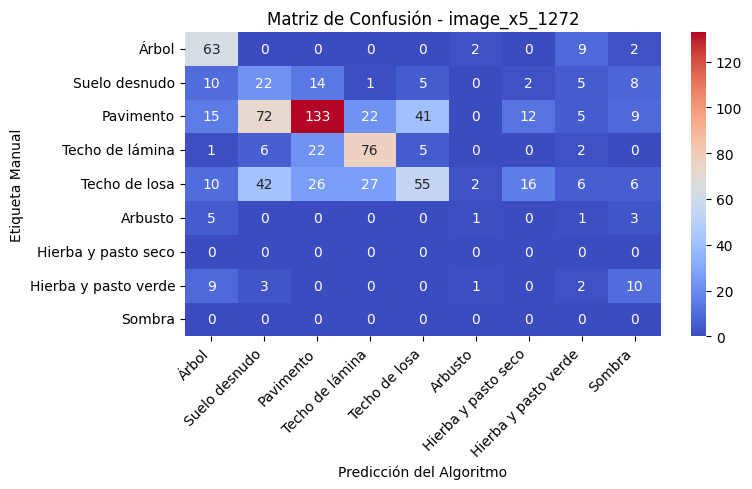


* Reporte de clases predichas erróneamente en 'image_x5_2448':
--------------------------------------------------------
'Pavimento' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 40 veces
   Total de errores para esta clase: 40

'Techo de lámina' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 6 veces
   - Hierba y pasto seco: 1 veces
   Total de errores para esta clase: 7

'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 25 veces
   - Arbusto: 1 veces
   - Hierba y pasto seco: 9 veces
   Total de errores para esta clase: 35

Clases ausentes en ambos archivos:
 - Cuerpo de agua


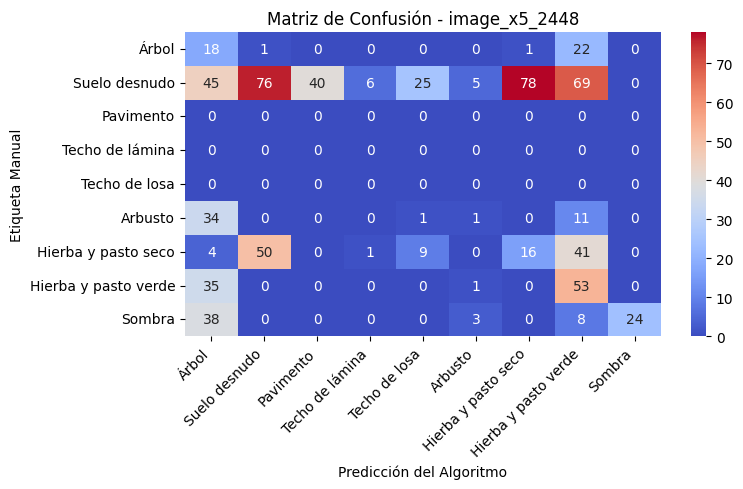


* Reporte de clases predichas erróneamente en 'image_x5_250':
--------------------------------------------------------
'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 16 veces
   - Pavimento: 21 veces
   - Techo de lámina: 7 veces
   - Arbusto: 1 veces
   - Hierba y pasto verde: 1 veces
   - Sombra: 3 veces
   Total de errores para esta clase: 49

'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 18 veces
   - Pavimento: 15 veces
   - Techo de lámina: 4 veces
   - Sombra: 2 veces
   Total de errores para esta clase: 39

Clases ausentes en ambos archivos:
 - Cuerpo de agua


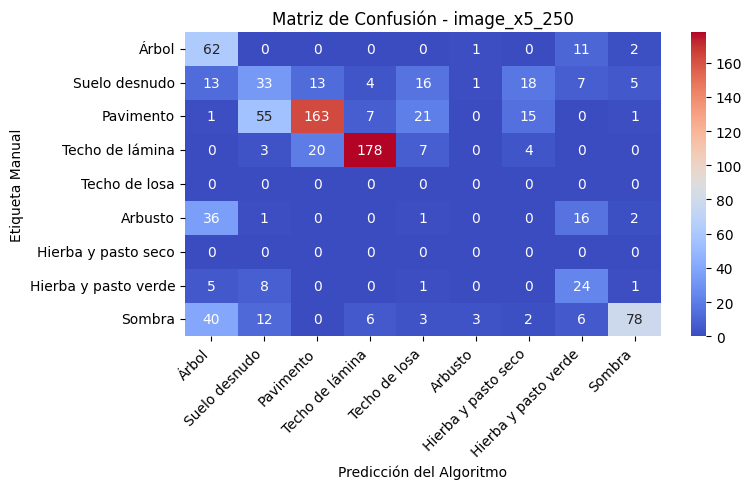


* Reporte de clases predichas erróneamente en 'image_x5_181':
--------------------------------------------------------
'Pavimento' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 14 veces
   - Hierba y pasto seco: 1 veces
   Total de errores para esta clase: 15

'Techo de lámina' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 5 veces
   Total de errores para esta clase: 5

'Techo de losa' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 27 veces
   - Hierba y pasto seco: 3 veces
   Total de errores para esta clase: 30

'Arbusto' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Árbol: 6 veces
   - Suelo desnudo: 5 veces
   - Sombra: 3 veces
   Total de errores para esta clase: 14

Clases ausentes en ambos archivos:
 - Cuerpo de agua


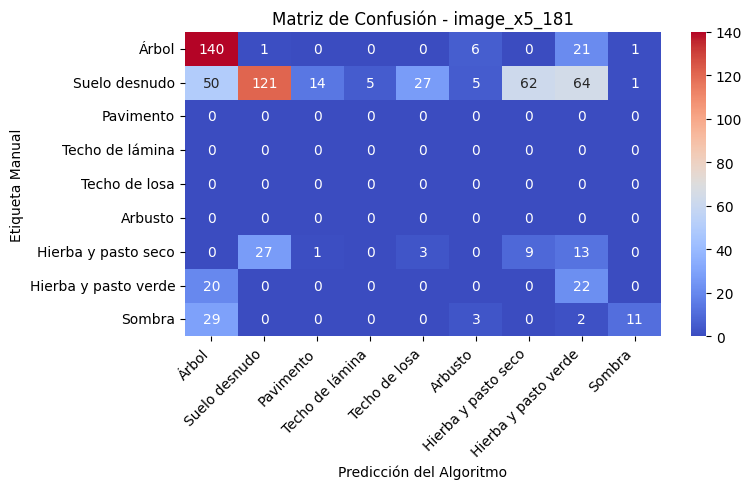


* Reporte de clases predichas erróneamente en 'image_x5_4037':
--------------------------------------------------------
'Hierba y pasto seco' fue predicha pero nunca estuvo en etiquetas reales.
   Se confundió con:
   - Suelo desnudo: 1 veces
   - Pavimento: 1 veces
   - Techo de losa: 2 veces
   - Hierba y pasto verde: 2 veces
   Total de errores para esta clase: 6



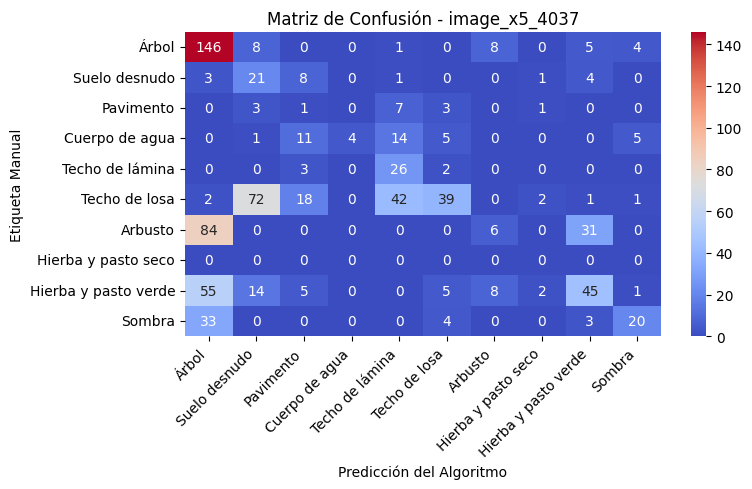

In [ ]:
# =========================================================
# Listas para almacenar resultados de precisión y errores por imagen
# =========================================================
resultados_precision = []          # precisión general y por categoría
resumen_errores_imagen = []        # errores totales y clases ausentes por imagen


# =========================================================
# Lista para almacenar TP, FP, FN, TN y soporte por imagen y por clase
# =========================================================
resultados_detalle_confusion = []
metricas_globales_img= []
# =========================================================
# Procesar cada imagen (archivo Caract_paralelo_*)
# =========================================================
for archivo_caract in archivos_caract:

    # nombre base de imagen
    nombre_imagen = archivo_caract.replace("Caract_paralelo_", "").replace(".csv", "")
    archivo_etiquetado = f"Etiquetado_{nombre_imagen}.csv"

    # Verificar si existe el archivo de etiquetado manual
    path_etiquetado = ruta_etiquetas_manuales / archivo_etiquetado
    if not path_etiquetado.exists():
        print(f"No se encontró el archivo etiquetado para {nombre_imagen}. Saltando...")
        continue

    # -------------------------
    # Cargar predicción y manual
    # -------------------------
    path_caract = ruta_predicciones_modelo / archivo_caract

    df_caract = pd.read_csv(path_caract, usecols=["indice", "prediction"])
    df_etiquetado = pd.read_csv(path_etiquetado, usecols=["indice", "categoria"])

    df_caract["indice"] = df_caract["indice"].astype(int)
    df_etiquetado["indice"] = df_etiquetado["indice"].astype(int)

    # -------------------------
    # Emparejar por índice
    # -------------------------
    df_comparacion = df_etiquetado.merge(df_caract, on="indice", how="left")
    df_comparacion.rename(columns={
        "categoria": "Etiqueta_Manual",
        "prediction": "Prediccion_Algoritmo"
    }, inplace=True)

    # Eliminar superpíxeles "Sin etiqueta" (clase 10)
    df_comparacion = df_comparacion[df_comparacion["Etiqueta_Manual"] != 10]

    if df_comparacion.empty:
        print(f"La imagen {nombre_imagen} no tiene clases distintas de 10. Saltando...")
        continue
    
    # ==========================
    # Definir clases presentes 
    # ==========================
    clases_etiquetadas = set(df_comparacion["Etiqueta_Manual"].unique())
    clases_predichas  = set(df_comparacion["Prediccion_Algoritmo"].unique())
    
    # Identificar clases ausentes en ambos archivos
    clases_no_aparecen = []
    clases_a_graficar = []

    clases_a_graficar = []
    for c in categorias.keys():
        if c == 10:
            continue
        esta_en_etiquetas     = c in clases_etiquetadas
        esta_en_predicciones  = c in clases_predichas

        if not esta_en_etiquetas and not esta_en_predicciones:
            clases_no_aparecen.append(categorias[c])
        else:
            clases_a_graficar.append(c)


    # ==========================
    # Matriz de confusión para esta imagen NUEVO
    # ==========================
    y_true = df_comparacion["Etiqueta_Manual"].values
    y_pred = df_comparacion["Prediccion_Algoritmo"].values

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=clases_a_graficar
    )
    etiquetas_mapeadas = [categorias[c] for c in clases_a_graficar]

    # cm es una matriz KxK donde:
    # filas    = clases reales     (Etiqueta_Manual)
    # columnas = clases predichas  (Prediccion_Algoritmo)

    total_pixeles = cm.sum()  # total de superpíxeles considerados en esta imagen

    # ==========================
    # Calcular TP, FP, FN, TN y soporte por clase
    # ==========================
    sum_support = sum_p_weighted = sum_r_weighted = sum_f1_weighted = sum_support_f1= 0.0

    for idx, clase in enumerate(clases_a_graficar):
        nombre_clase = categorias[clase]
            
        
        tp = cm[idx, idx]           # diagonal
        fp = cm[:, idx].sum() - tp  # columna clase - tp
        fn = cm[idx, :].sum() - tp  # fila clase - tp
        tn = total_pixeles - tp - fp - fn     # todo lo demás
        
        support = tp + fn   # nº de ejemplos reales de esta clase

        if support > 0:
            # Hay ejemplos reales de la clase (caso 1 o 2)

            # --- Precision ---
            if tp > 0:
                precision = tp / (tp + fp)
                recall= tp / (tp + fn)
                f1_score = 2 * ( (precision * recall)/ (precision +recall))
            else:
                # Caso 2: hay etiquetas reales, pero nunca se predijo la clase, es decir TP=0
                precision = 0.0
                recall = 0.0
                f1_score = np.nan
            

            # Acumular para weighted (solo clases con soporte>0)
            # Para P y R sí usamos siempre support
            sum_support += support
            sum_p_weighted += support * precision
            sum_r_weighted += support * recall

            # Acumular para weighted F1 SOLO si F1 está definida
            if not np.isnan(f1_score):
                sum_f1_weighted += support * f1_score
                sum_support_f1  += support

        else:
            # support == 0,   casos 3 
            if (tp + fp) > 0:
                # CASO 3: No en etiquetas, Sí en predicción
                precision = 0.0
                recall = np.nan
                f1_score= np.nan
            else:
                # CASO 4: No en etiquetas, No en predicción
                precision = np.nan
                recall = np.nan
                f1_score = np.nan
            # No se acumula nada en los weighted
    
        soporte = cm[idx, :].sum()            # = tp + fn = nº reales de esa clase

        resultados_detalle_confusion.append({
            "Imagen": nombre_imagen,
            "Clase_ID": clase,
            "Clase_nombre": nombre_clase,
            "TP": int(tp),
            "FP": int(fp),
            "FN": int(fn),
            "TN": int(tn),
            "support": int(soporte),
            "Pre.": precision,
            "Rec.": recall, 
            "F1": f1_score,
            "total_pixeles_imagen": int(total_pixeles)
        })
        
    # ==========================
    # Reporte de errores (Caso 3)
    # ==========================
    errores_predicciones = []

    print(f"\n* Reporte de clases predichas erróneamente en '{nombre_imagen}':")
    print("--------------------------------------------------------")

    for clase_predicha in categorias.keys():
        if clase_predicha == 10:
            continue

        nombre_clase = categorias[clase_predicha]

        fue_predicha = (df_comparacion["Prediccion_Algoritmo"] == clase_predicha).any()
        existe_en_verdaderas = (df_comparacion["Etiqueta_Manual"] == clase_predicha).any()

        if fue_predicha and not existe_en_verdaderas:
            errores_df = df_comparacion[df_comparacion["Prediccion_Algoritmo"] == clase_predicha]
            conteo_confusiones = errores_df["Etiqueta_Manual"].value_counts().sort_index()

            print(f"'{nombre_clase}' fue predicha pero nunca estuvo en etiquetas reales.")
            print("   Se confundió con:")
            for clase_real, conteo in conteo_confusiones.items():
                nombre_real = categorias.get(int(clase_real), "Desconocida")
                print(f"   - {nombre_real}: {conteo} veces")
            print(f"   Total de errores para esta clase: {len(errores_df)}\n")

            errores_predicciones.append({
                "Clase_predicha": nombre_clase,
                "ID": clase_predicha,
                "Total_errores": len(errores_df),
                "Confusiones": dict(conteo_confusiones.map(int))
            })

    # Caso 4: ausentes en ambos
    if clases_no_aparecen:
        print("Clases ausentes en ambos archivos:")
        for clase_nombre in clases_no_aparecen:
            print(f" - {clase_nombre}")

    total_errores_imagen = sum(e["Total_errores"] for e in errores_predicciones)
    resumen_errores_imagen.append({
        "Imagen": nombre_imagen,
        "Errores_totales_predichos_erróneamente": total_errores_imagen,
        "Clases_ausentes": clases_no_aparecen
    })

    # ==========================
    # Graficar matriz de confusión
    # ==========================
    plt.figure(figsize=(8, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="coolwarm",
        xticklabels=etiquetas_mapeadas,
        yticklabels=etiquetas_mapeadas
    )
    plt.xlabel("Predicción del Algoritmo")
    plt.ylabel("Etiqueta Manual")
    plt.title(f"Matriz de Confusión - {nombre_imagen}")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
        
        
    # ---- Métricas globales weighted por imagen ----
    if sum_support > 0:
        weighted_p = (sum_p_weighted / sum_support) * 100
        weighted_r = (sum_r_weighted / sum_support) * 100
    else:
        weighted_p = np.nan
        weighted_r = np.nan

    if sum_support_f1 > 0:
        weighted_f1 = (sum_f1_weighted / sum_support_f1) * 100
    else:
        weighted_f1 = np.nan

    metricas_globales_img.append({
        "Imagen": nombre_imagen,
        "Pre_w": weighted_p,
        "Rec_w": weighted_r,
        "F1_w": weighted_f1
    })
    

# =========================================================
# DataFrame final con TP, FP, FN, TN, soporte por imagen y clase, precision, recall, f1-score
# =========================================================
df_detalle_confusion = pd.DataFrame(resultados_detalle_confusion)
df_metricas_globales_img = pd.DataFrame(metricas_globales_img)
df_errores = pd.DataFrame(resumen_errores_imagen)


In [5]:
print(df_detalle_confusion.to_string())

            Imagen  Clase_ID          Clase_nombre   TP   FP   FN   TN  support      Pre.      Rec.        F1  total_pixeles_imagen
0     image_x5_176         0                 Árbol   16   26    4  827       20  0.380952  0.800000  0.516129                   873
1     image_x5_176         1         Suelo desnudo    5   73    6  789       11  0.064103  0.454545  0.112360                   873
2     image_x5_176         2             Pavimento  100   69   48  656      148  0.591716  0.675676  0.630915                   873
3     image_x5_176         3        Cuerpo de agua    0    2    0  871        0  0.000000       NaN       NaN                   873
4     image_x5_176         4       Techo de lámina  340    8  107  418      447  0.977011  0.760626  0.855346                   873
5     image_x5_176         5         Techo de losa   28   26   43  776       71  0.518519  0.394366  0.448000                   873
6     image_x5_176         6               Arbusto    0    2    6  865      

#
<div class="alert alert-block alert-success">
<b>Dataframe del resumen de errores por clase no presente en etiquetas (caso 3) y clases ausentes en ambos
archivos (caso 4)</b></div>

In [6]:
df_errores

,Imagen,Errores_totales_predichos_erróneamente,Clases_ausentes
0,image_x5_176,15,[]
1,image_x5_1730,65,[]
2,image_x5_3628,47,[Cuerpo de agua]
3,image_x5_1797,15,[]
4,image_x5_172,27,[Cuerpo de agua]
5,image_x5_221,24,[]
6,image_x5_3913,29,[]
7,image_x5_174,72,[Cuerpo de agua]
8,image_x5_164,15,[Cuerpo de agua]
9,image_x5_201,150,[Cuerpo de agua]



#
<div class="alert alert-block alert-success">
<b>Metricas globales y por categoría, para cada una de las imagenes de prueba</b></div>

In [ ]:
# Convertir precisiones por clase a porcentaje
df_detalle_confusion["Pre_w"] = df_detalle_confusion["Pre."] * 100.0


# TABLA DE PRECISION
tabla_prec = (
    df_detalle_confusion
        .pivot(index="Imagen", columns="Clase_ID", values="Pre_w")
        .rename(columns=categorias)
)

tabla_prec = (
    df_metricas_globales_img
        .set_index("Imagen")[["Pre_w"]]
        .join(tabla_prec, how="left")
)
tabla_prec

,Pre_w,Árbol,Suelo desnudo,Pavimento,Cuerpo de agua,Techo de lámina,Techo de losa,Arbusto,Hierba y pasto seco,Hierba y pasto verde,Sombra
Imagen,,,,,,,,,,,
image_x5_176,82.952374,38.095238,6.410256,59.171598,0.000000,97.701149,51.851852,0.000000,0.000000,46.153846,95.683453
image_x5_1730,65.708618,4.210526,14.545455,0.000000,100.000000,0.000000,0.000000,43.269231,0.000000,40.689655,79.245283
image_x5_3628,56.608120,42.896175,20.879121,70.312500,NaN,95.061728,26.530612,29.411765,0.000000,53.846154,40.625000
image_x5_1797,71.298130,12.000000,7.100592,86.075949,0.000000,87.795276,48.780488,0.000000,0.000000,14.285714,91.358025
image_x5_172,65.898582,48.510638,61.904762,22.807018,NaN,98.809524,20.338983,14.285714,0.000000,11.594203,0.000000
image_x5_221,67.890543,7.792208,60.000000,0.000000,0.000000,96.195652,53.225806,8.333333,0.000000,59.183673,95.312500
image_x5_3913,63.376095,10.352423,17.021277,0.000000,99.328859,0.000000,0.000000,62.500000,0.000000,31.081081,71.794872
image_x5_174,67.983666,64.871194,18.750000,0.000000,NaN,100.000000,0.000000,12.500000,0.000000,65.550239,0.000000
image_x5_164,69.108946,66.445183,68.421053,1.369863,NaN,97.222222,6.250000,26.315789,0.000000,9.722222,71.111111


In [ ]:
# TABLA DE RECALL
df_detalle_confusion["Rec_w"] = df_detalle_confusion["Rec."] * 100.0


tabla_recall = (
    df_detalle_confusion
        .pivot(index="Imagen", columns="Clase_ID", values="Rec_w")
        .rename(columns=categorias)
)

tabla_recall = (
    df_metricas_globales_img
        .set_index("Imagen")[["Rec_w"]]
        .join(tabla_recall, how="left")
)
tabla_recall


,Rec_w,Árbol,Suelo desnudo,Pavimento,Cuerpo de agua,Techo de lámina,Techo de losa,Arbusto,Hierba y pasto seco,Hierba y pasto verde,Sombra
Imagen,,,,,,,,,,,
image_x5_176,72.623139,80.000000,45.454545,67.567568,NaN,76.062640,39.436620,0.000000,NaN,75.000000,86.363636
image_x5_1730,31.749460,57.142857,53.333333,NaN,50.000000,NaN,NaN,21.428571,NaN,32.240437,17.355372
image_x5_3628,48.195329,90.229885,46.341463,26.162791,NaN,77.777778,35.616438,4.901961,NaN,26.315789,26.530612
image_x5_1797,55.314286,100.000000,31.578947,52.307692,NaN,87.450980,15.503876,0.000000,NaN,31.818182,63.793103
image_x5_172,56.461731,78.082192,44.444444,24.074074,NaN,70.338983,30.000000,3.076923,NaN,38.095238,NaN
image_x5_221,49.885321,75.000000,55.769231,0.000000,NaN,78.318584,25.984252,2.702703,NaN,29.591837,62.886598
image_x5_3913,33.413174,94.000000,40.000000,NaN,63.519313,NaN,NaN,12.315271,0.000000,12.921348,18.791946
image_x5_174,62.124711,80.523256,15.789474,NaN,NaN,65.555556,NaN,5.357143,NaN,51.310861,NaN
image_x5_164,57.055215,90.909091,47.560976,9.090909,NaN,54.901961,6.896552,6.756757,NaN,50.000000,66.666667


In [9]:
# TABLA DE F1-SCORE
df_detalle_confusion["F1_w"] = df_detalle_confusion["F1"] * 100.0

# 2) Tabla ancha por imagen x clase, usando F1_pct
tabla_f1 = (
    df_detalle_confusion
        .pivot(index="Imagen", columns="Clase_ID", values="F1_w")
        .rename(columns=categorias)
)

# 3) Añadir F1_w (weighted por imagen) a la izquierda
tabla_f1 = (
    df_metricas_globales_img
        .set_index("Imagen")[["F1_w"]]   # ya está en porcentaje
        .join(tabla_f1, how="left")
)

tabla_f1

,F1_w,Árbol,Suelo desnudo,Pavimento,Cuerpo de agua,Techo de lámina,Techo de losa,Arbusto,Hierba y pasto seco,Hierba y pasto verde,Sombra
Imagen,,,,,,,,,,,
image_x5_176,77.051128,51.612903,11.235955,63.091483,NaN,85.534591,44.800000,NaN,NaN,57.142857,90.784983
image_x5_1730,39.513273,7.843137,22.857143,NaN,66.666667,NaN,NaN,28.662420,NaN,35.975610,28.474576
image_x5_3628,46.867610,58.148148,28.787879,38.135593,NaN,85.555556,30.409357,8.403361,NaN,35.353535,32.098765
image_x5_1797,62.673091,21.428571,11.594203,65.071770,NaN,87.622790,23.529412,NaN,NaN,19.718310,75.126904
image_x5_172,58.743836,59.842520,51.741294,23.423423,NaN,82.178218,24.242424,5.063291,NaN,17.777778,NaN
image_x5_221,56.245098,14.117647,57.807309,NaN,NaN,86.341463,34.920635,4.081633,NaN,39.455782,75.776398
image_x5_3913,37.609917,18.650794,23.880597,NaN,77.486911,NaN,NaN,20.576132,NaN,18.253968,29.787234
image_x5_174,63.612129,71.854734,17.142857,NaN,NaN,79.194631,NaN,7.500000,NaN,57.563025,NaN
image_x5_164,59.547725,76.775432,56.115108,2.380952,NaN,70.175439,6.557377,10.752688,NaN,16.279070,68.817204
